# ตัวอย่างการเรียกใช้งาน CNN โดยใช้ข้อมูลของ Fashion MNIST
จัดทำโดย อ.ดร.ภูริวัจน์ วรวิชัยพัฒน์

อย่างที่กล่าวไปในคาบว่า การฝึกฝน CNN นั้นใช้เวลาในการฝึกสูงมากๆ ซึ่งวิธีการแก้ปัญหาก็คือต้องใช้ GPU ในการเทรนโมเดลของเราแทน

กระบวนการที่ต้องทำทุกๆครั้งเลยคือต้องตรวจสอบว่า <font color="blue">**เครื่องของเรานั้นมองเห็น GPU หรือไม่**</font> ซึ่งโค้ดด้านล่างเป็นการตรวจสอบนั้น

```python
    import tensorflow as tf
    tf.config.list_physical_devices()
```


In [2]:
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

tf.config.list_physical_devices()

2.21.0
3.15.0


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

## จัดการข้อมูล
ต้องมีการปรับ หรือ reshape ข้อมูลนิดหน่อย <font color="blue">เพื่อให้สอดคล้องกับตัว CNN ที่เป็น 2 มิติ</font> 
<br> โดยแต่ละมิติเป็นดังนี้ (จำนวนภาพ, ค.กว้าง, ค.ยาว, มิติสี) ในที่นี้ภาพเป็นขาวดำจึงมีทั้งหมด 1 มิติสีเท่านั้น

In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.astype(np.float32) / 255
test_images = test_images.astype(np.float32) / 255

ภาพมี 60000 ภาพ แต่ละภาพขนาด 28x28 มี 1 มิติสี (greyscale) จึงต้อง reshape เป็น
> (60000, 28, 28, 1)

ก่อนหน้านี้ shape จะเป็น (60000, 28, 28)

In [4]:
train_images = train_images.reshape(60000, 28, 28, 1)
test_images = test_images.reshape(10000, 28, 28, 1)

## สร้างโมเดล
`input_shape = (28, 28, 1)` เพื่อบอกว่าภาพมีขนาด 28 x 28 และ 1 มิติสีเท่านั้น **ถ้าภาพเป็น RGB จะเป็น (28, 28, 3)**

คำสั่ง Conv2D นั้นสามารถปรับแต่งได้หลายอย่าง:
1. จำนวน filters หรือ features ที่ต้องการ ณ ที่นี้กำหนดเป็น `32`
2. ขนาดของ filter ว่าอยากให้กว้างเท่าไหร่ ตอนนี้ใช้ 3x3 (มักเป็นเลขคี่เพื่อให้มีตน. anchor) 
3. activation function ตอนนี้ใช้เป็น Rectified Linear Unit (ReLu)
4. `padding = 'same'` คืออะไร?
> เนื่องจากว่า Filter นั้นมีขนาด 3x3 ซึ่งก็จะหลีกเลี่ยงไม่ได้เลยว่าตรงขอบของภาพจะไม่ได้ถูกพิจารณา การสั่ง padding เป็นการเติมขอบของรูปภาพออกไปเพื่อให้ filter นั้นพิจารณาตรงขอบด้วย <font color="blue">'same' หมายความว่าให้เติมส่วนขอบด้วยเลข 0 (zero padding)</font>

In [6]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation=tf.nn.relu, padding='same', 
                        input_shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
history = model.fit(train_images, train_labels, batch_size=128, 
                    validation_data=(test_images, test_labels), epochs=20)

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       250,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,210 (981.29 KB)

 Trainable params: 251,210 (981.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8460 - loss: 0.4431 - val_accuracy: 0.8760 - val_loss: 0.3503
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8951 - loss: 0.2982 - val_accuracy: 0.8891 - val_loss: 0.3115
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9057 - loss: 0.2633 - val_accuracy: 0.8901 - val_loss: 0.3006
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9142 - loss: 0.2389 - val_accuracy: 0.8946 - val_loss: 0.2945
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9207 - loss: 0.2202 - val_accuracy: 0.8970 - val_loss: 0.2856
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9264 - loss: 0.2054 - val_accuracy: 0.9011 - val_loss: 0.2817
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9306 - loss: 0.1934 - val_accuracy: 0.9015 - val_loss: 0.2842
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9351 - loss: 0.1819 - val_accu

## วิเคราะห์
- จะสังเกตุได้ว่าพอเราหันมาใช้ CNN ที่มองภาพเป็นส่วนๆแล้ว acc นั้นดีขึ้นอย่างเห็นได้ชัด
- ที่สำคัญไปกว่านั้น loss ก็ต่ำมากๆเช่นกัน
- เพียงแค่ไม่กี่ epoch ก็ได้ accuracy ประมาณ 90% แล้ว แสดงว่าวิธีของ CNN เหมือนจะดีกว่า

**แต่จะสังเกตุได้ว่ามันยังดูจะไม่เก่งเมื่อเจอข้อมูลที่ไม่เคยเห็น ดูที่ค่า `val_accuracy` กับ `val_loss`**


ด้านล่างจะเป็นฟังก์ชัน `plot_history` ที่ใส่เพียง history ก็สามารถพล็อตกราฟของ acc และ loss ออกมาได้ทันที

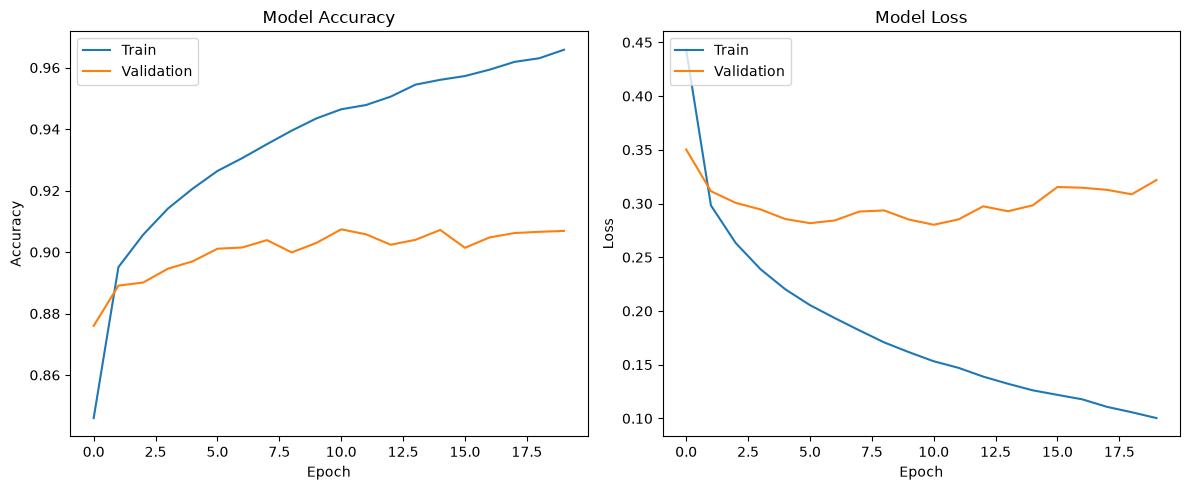

In [7]:

def plot_history(history):
    """
    Plots the training and validation accuracy and loss from the training history.
    
    Args:
    - history: A History object. The history object is returned by the `fit` method of a Keras model.
    """
    # Plot accuracy history
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    # Plot loss history
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.tight_layout()
    plt.show()

plot_history(history)


## วิเคราะห์ผลลัพธ์

- Accuracy 

> จะเห็นได้ว่าความแม่นยำในระหว่างฝึกนั้นเพิ่มสูงขึ้นเรื่อยๆ จนได้ความแม่นยำที่ 95+% <br>
แต่เมื่อดูที่ผลของ test จะเห็นว่าความเม่นยำจะคงที่อยู่ที่ ***90%*** <br>

- Loss

> ค่าความห่างจากเฉลยหรือ loss นั้นลดลงเมื่อจำนวนรอบเพิ่มขึ้น <br>
แต่ดูเหมือนว่า ผล loss ที่ผ่านข้อมูล validation เข้ามานั้นมีแนวโน้มที่เพิ่มขึ้นอย่างเห็นได้ชัด ***ซึ่งถือว่าไม่ดี***

## ทดลองเพิ่ม Layer Dense64 จะเกิดอะไรขึ้น?

- การเพิ่มชั้น hidden layer เข้าไปต้องการให้โมเดลนั้นมี weights ที่เยอะขึ้น หรือ**จดจำข้อมูลได้มากขึ้น**
- ซึ่งอาจจะทำให้เกิดผลข้างเคียงออกมาได้ เดี๋ยวมาดูกันว่าเกิดอะไรขึ้น?

```python
keras.layers.Dense(64, activation="relu"),
``` 
ชั้นนี้จะถูกเพิ่มเข้ามา

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,606,666 (6.13 MB)

 Trainable params: 1,606,666 (6.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8450 - loss: 0.4425 - val_accuracy: 0.8626 - val_loss: 0.3749
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8954 - loss: 0.2937 - val_accuracy: 0.8850 - val_loss: 0.3146
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9112 - loss: 0.2453 - val_accuracy: 0.8928 - val_loss: 0.2936
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9242 - loss: 0.2112 - val_accuracy: 0.8952 - val_loss: 0.2923
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9323 - loss: 0.1873 - val_accuracy: 0.8958 - val_loss: 0.3040
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9390 - loss: 0.1671 - val_accuracy: 0.9017 - val_loss: 0.2927
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9468 - loss: 0.1465 - val_accuracy: 0.9015 - val_loss: 0.2888
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9544 - loss: 0.1271 - val_a

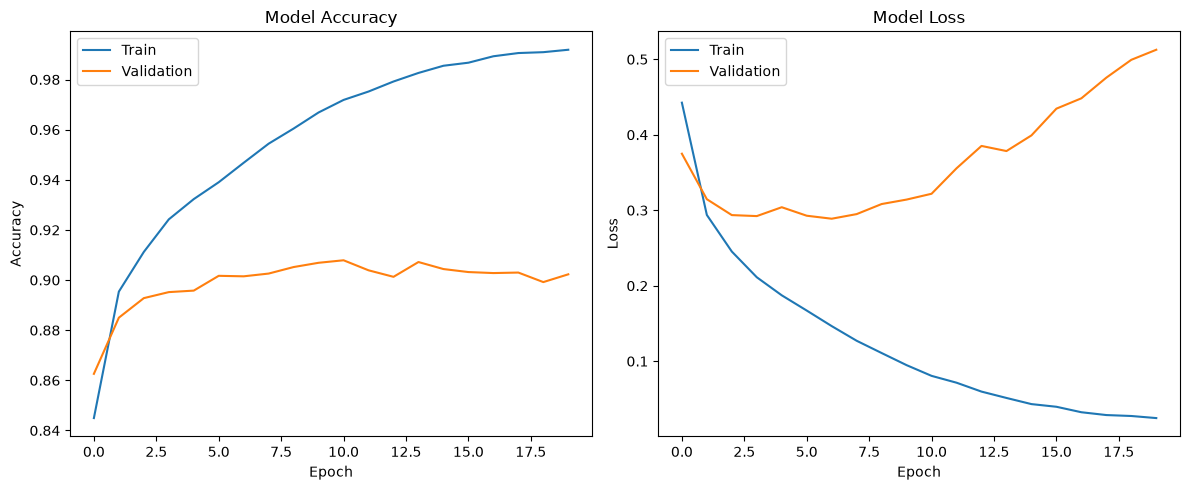

In [8]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation=tf.nn.relu, padding='same', # <---- คงจำนวน filter ไว้เท่าเดิม (32) เพื่อให้เห็นผลจากการเพิ่ม Dense layer เพียงอย่างเดียว
                        input_shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"), # <---- ชั้นนี้จะถูกเพิ่มเข้ามา
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
history = model.fit(train_images, train_labels, batch_size=128, 
                    validation_data=(test_images, test_labels), epochs=20)
plot_history(history)


## ปัญหา Overfitting
เมื่อดูกราฟจะเห็นว่า loss ของ validation นั้นสูงขึ้นอย่างชัดเจนและไม่มีวี่แววจะลดลงเลยแต่อย่างใด สัญญาณอีกอย่างคือ accuracy นั้นขึ้นไปเกือบเท่ากับ 100% แปลว่าโมเดลจำ training ได้ดีเกินไป!! **<font color="blue">เกิดปัญหา Overfitting แน่ๆ</font>**
> accuracy: <font color="blue">0.9963</font> - loss: 0.0123 - val_accuracy: 0.9013 - val_loss: <font color="blue">0.5510</font>

1 ในวิธีแก้ที่เราได้เรียนไปคือการใช้ Dropout ซึ่งสามารถเพิ่ม layer dropout ได้ตามโค้ดด้านล่าง สิ่งที่ต้องปรับคือ *<font color="blue">ความน่าจะเป็นที่จะให้ node นั้นๆหายไป</font>* เช่น
> ```python
> keras.layers.Dropout(0.25), # <---- เลเยอร์ก่อนหน้า มีโอกาส node หายไป 25% 
> keras.layers.Dropout(0.30), # <---- เลเยอร์ก่อนหน้า มีโอกาส node หายไป 30% 
> keras.layers.Dropout(0.50), # <---- เลเยอร์ก่อนหน้า มีโอกาส node หายไป 50% 

## <font color="red">แบบฝึกหัดที่ 1 เพิ่ม dropout</font>

dropout สามารถเพิ่มได้ 2 ตำแหน่งคือ

**หลังจาก Flatten:**
```python
model = keras.Sequential([
    keras.layers.Conv2D(64, (3,3), activation=tf.nn.relu, padding='same', 
                        input_shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
```

**หรือหลังจาก Dense:**
```python
model = keras.Sequential([
    keras.layers.Conv2D(64, (3,3), activation=tf.nn.relu, padding='same', 
                        input_shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
```

- หรือจะเพิ่มไว้ทั้งหลัง Flatten และ Dense

1. จงทดลองใช้งาน dropout ที่ความน่าจะเป็นแตกต่างกันออกไป
   1. dropout หลัง Flatten() ที่ 25%, 30%, และ 50% บันทึก accuracy, loss, val_accuracy, และ val_loss สุดท้ายของแต่ละ setting ด้วย <font color="blue">**โค้ดด้านล่างถูกใช้ซ้ำทั้ง 3 รอบ ให้บันทึกผลลงในช่องคำตอบด้านล่างก่อนแก้ค่า dropout แล้วรันใหม่ทุกครั้ง มิฉะนั้นผลลัพธ์รอบก่อนหน้าจะหายไป**</font>
   2. สรุปหน่อยว่า dropout ที่เท่าไหร่ดีที่สุด
2. ปรับแต่งอย่างอิสระ ให้นศ.คิดโครงสร้างโมเดลที่คิดว่าให้ผลดีที่สุด (ดูที่ val_accuracy, และ val_loss )
   - สามารถใช้ dropout ที่กี่ % ก็ได้ (มักจะไม่ให้เกิน 50% มิฉะนั้นข้อมูลจะหลุดไปยัง output น้อยเกินไป)
   - วาง dropout 1 ครั้งหรือ 2 ครั้งก็ได้
   - จะเพิ่มจำนวน filter ก็ได้เช่นเป็น 48, 64
   - และอย่าลืมดูกราฟด้วย พยายามเพิ่ม val_accuracy แต่อย่าให้ val_loss สูงขึ้น

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,441,098 (24.57 MB)

 Trainable params: 6,441,098 (24.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - accuracy: 0.7801 - loss: 0.6252 - val_accuracy: 0.8687 - val_loss: 0.3588
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - accuracy: 0.8585 - loss: 0.4027 - val_accuracy: 0.8815 - val_loss: 0.3256
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - accuracy: 0.8747 - loss: 0.3495 - val_accuracy: 0.8871 - val_loss: 0.3053
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - accuracy: 0.8842 - loss: 0.3199 - val_accuracy: 0.8940 - val_loss: 0.2912
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 80ms/step - accuracy: 0.8924 - loss: 0.2955 - val_accuracy: 0.8951 - val_loss: 0.2836
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 80ms/step - accuracy: 0.8967 - loss: 0.2830 - val_accuracy: 0.8976 - val_loss: 0.2770
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - accuracy: 0.9025 - loss: 0.2637 - val_accuracy: 0.9035 - val_loss: 0.2686
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - accuracy: 0.9059 - loss: 0.2550 - 

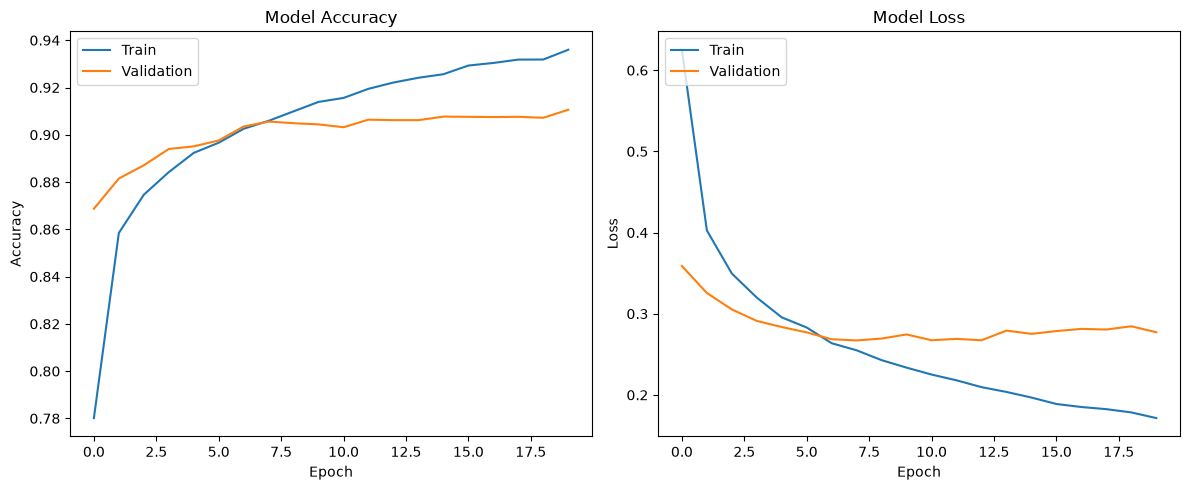

In [23]:
# โค้ดทดลองใช้ dropout หลายๆความน่าจะเป็น
model = keras.Sequential([
    keras.layers.Conv2D(64, (3,3), activation=tf.nn.relu,            # <---- แก้จำนวน filter ได้
                        padding='same', input_shape=(28, 28, 1)), 
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),                  
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),                   
    keras.layers.Dense(128, activation="relu"),     # <---- เพิ่ม??
    keras.layers.Dropout(0.25),                  # <---- แก้ dropout เอากี่ % หรือไม่เอาเลย
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
history = model.fit(train_images, train_labels, batch_size=128, 
                    validation_data=(test_images, test_labels), epochs=20)
plot_history(history)


<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 1 A

| dropout | accuracy | loss | val_accuracy | val_loss |
|---|---|---|---|---|
| 25% | 0.9864 | 0.0376 | 0.9015 | 0.4646 |
| 30% | 0.9818 | 0.0500 | 0.9007 | 0.4078 |
| 50% | 0.9744 | 0.0686 | 0.9081 | 0.3602 |

ข้อที่ 1 B
> this is the model I have choosen:
> 
> model = keras.Sequential([
>    keras.layers.Conv2D(64, (3,3), activation=tf.nn.relu,            # <---- แก้จำนวน filter ได้
                        padding='same', input_shape=(28, 28, 1)), 
>    keras.layers.Flatten(),
>    keras.layers.Dropout(0.5),                  
>    keras.layers.Dense(128, activation="relu"),
>    keras.layers.Dropout(0.5),                   
>    keras.layers.Dense(128, activation="relu"),     # <---- เพิ่ม??
>    keras.layers.Dropout(0.25),                  # <---- แก้ dropout เอากี่ % หรือไม่เอาเลย
>    keras.layers.Dense(10, activation=tf.nn.softmax)
>])
> 
> this is the best model so far as it give better val_acc and val_loss than the other 3 models:
> 
> accuracy: 0.9360 - loss: 0.1715 - val_accuracy: 0.9106 - val_loss: 0.2772

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,220,618 (12.29 MB)

 Trainable params: 3,220,618 (12.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.7910 - loss: 0.5959 - val_accuracy: 0.8722 - val_loss: 0.3594
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.8648 - loss: 0.3887 - val_accuracy: 0.8852 - val_loss: 0.3159
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.8815 - loss: 0.3341 - val_accuracy: 0.8946 - val_loss: 0.2922
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.8900 - loss: 0.3024 - val_accuracy: 0.8928 - val_loss: 0.2930
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.9012 - loss: 0.2757 - val_accuracy: 0.8989 - val_loss: 0.2791
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9079 - loss: 0.2549 - val_accuracy: 0.9007 - val_loss: 0.2810
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9142 - loss: 0.2363 - val_accuracy: 0.9021 - val_loss: 0.2742
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.9178 - loss: 0.2214 - 

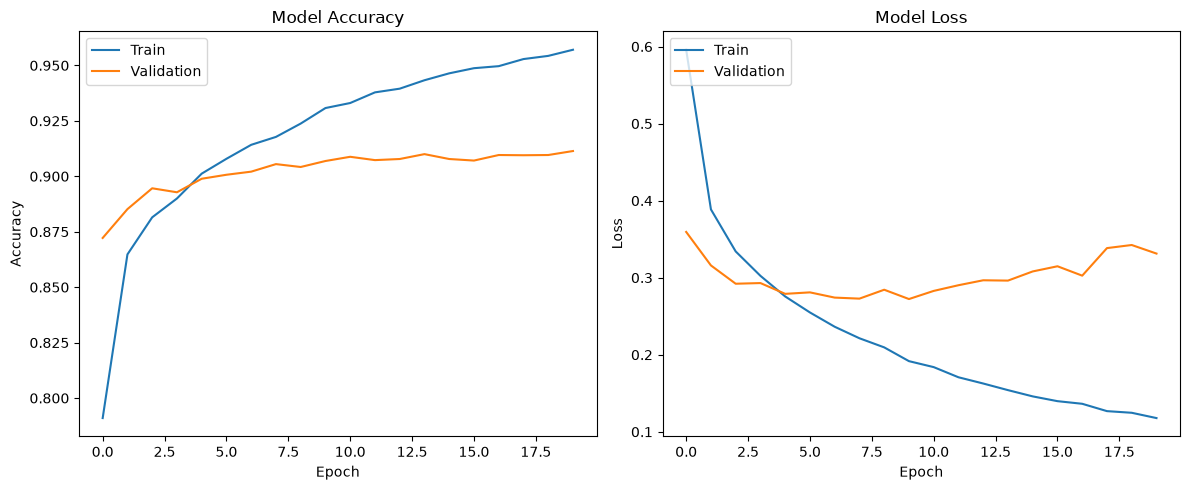

In [19]:
# โค้ดสำหรับข้อที่ 2 
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation=tf.nn.relu,            # <---- แก้จำนวน filter ได้
                        padding='same', input_shape=(28, 28, 1)), 
    keras.layers.Flatten(),
    # keras.layers.Dropout(0.25),                  # <---- แก้ dropout เอากี่ % หรือไม่เอาเลย
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),                   
    keras.layers.Dense(64, activation="relu"),     # <---- เพิ่ม??
    keras.layers.Dropout(0.25),                  # <---- แก้ dropout เอากี่ % หรือไม่เอาเลย
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
history = model.fit(train_images, train_labels, batch_size=64, 
                    validation_data=(test_images, test_labels), epochs=20)
plot_history(history)


<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 2 setting แบบไหนที่โมเดลยังคงได้ val_accuracy สูง และไม่เกิด overfitting
> my model use 2 dense layers (excluding output) and two dropout layers. I think this model prevent overfitting because the accuracy (0.9571) and validate accuracy (0.9114) is really similar after 20 epochs with batch_size 64. 


## <font color="red">แบบฝึกหัดที่ 2 เพิ่ม spatialDropout</font>

**ข้อควรระวังการใช้งาน dropout**

เนื่องจาก dropout แบบนี้เป็นการสุ่มปิด node จึงควรใช้งานกับ `Dense()` หรือ `flatten()` เท่านั้น โดยทั่วไปไม่แนะนำให้นำไปใช้ต่อหลังจาก Conv2D เพราะสิ่งที่เกิดขึ้นคือ มันจะไปสุ่มปิด feature map แทนหนะสิ เช่น

```
Original Feature Map:
[[0.9, 0.8, 0.7, 0.6],
 [0.5, 0.4, 0.3, 0.2],
 [0.1, 0.9, 0.8, 0.7],
 [0.6, 0.5, 0.4, 0.3]]

After Dropout (rate = 0.5):
[[0.0, 0.8, 0.0, 0.6],
 [0.5, 0.0, 0.3, 0.0],
 [0.1, 0.9, 0.0, 0.7],
 [0.0, 0.5, 0.4, 0.0]]
```

ค่า feature ของภาพที่ผ่าน filter นั้นหายไป เปรียบเสมือนกับ feature ที่มีจุดดำๆอยู่ข้างใน

แล้วจะแก้ไขอย่างไร? ถ้าอยากใส่ dropout ที่ Conv2D? จริงๆแล้วมี dropout ชนิดพิเศษที่เรียกว่า <font color="blue">spatial dropout</font>
1. นศ.จงค้นหาวิธีการใช้งาน spatial dropout (จาก chatGPT ก็ได้) สามารถเอาไปใช้งานร่วมกับ dropout จากแบบฝึกหัดที่แล้วได้ จากนั้นบันทึกด้วยว่าโมเดลทำงานได้ดีขึ้นหรือไม่
2. อธิบายว่าเหตุใดจึงเกิดตามข้อ 1.

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 28, 28, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,220,618 (12.29 MB)

 Trainable params: 3,220,618 (12.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - accuracy: 0.7841 - loss: 0.6212 - val_accuracy: 0.8683 - val_loss: 0.3680
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8580 - loss: 0.4093 - val_accuracy: 0.8799 - val_loss: 0.3260
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.8753 - loss: 0.3545 - val_accuracy: 0.8876 - val_loss: 0.3086
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.8864 - loss: 0.3201 - val_accuracy: 0.8922 - val_loss: 0.3009
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8930 - loss: 0.3005 - val_accuracy: 0.8970 - val_loss: 0.2856
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.8985 - loss: 0.2794 - val_accuracy: 0.9001 - val_loss: 0.2824
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9037 - loss: 0.2650 - val_accuracy: 0.9005 - val_loss: 0.2789
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9085 - loss: 0.2533 - 

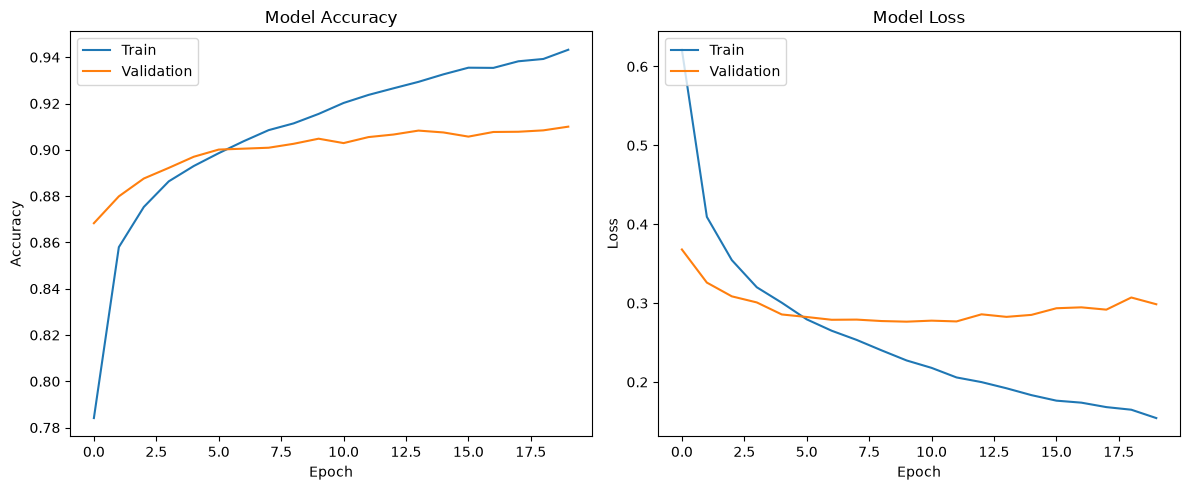

In [20]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation=tf.nn.relu, padding='same', input_shape=(28, 28, 1)),
    keras.layers.SpatialDropout2D(0.2), 
    
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),                    
    keras.layers.Dense(64, activation="relu"),    
    keras.layers.Dropout(0.25),                  
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer=keras.optimizers.Adam(), 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
history = model.fit(train_images, train_labels, batch_size=64, 
                    validation_data=(test_images, test_labels), epochs=20)
plot_history(history)


<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 1
> I used the SpatialDropout after convolution 32 so that 20% of this will be drop
> 
> keras.layers.Conv2D(32, (3,3), activation=tf.nn.relu, padding='same', input_shape=(28, 28, 1)),
> 
> keras.layers.SpatialDropout2D(0.2), 

ข้อที่ 2
> According to model summary, the spatialDropout doesn't seem to help the model much. Maybe the layers isn't much yet, but still it help impove a lot with the val_acc and val_loss (accuracy: 0.9432 - loss: 0.1542 - val_accuracy: 0.9100 - val_loss: 0.2986) which mean adding this layers help our model learn better.